## Binary Customer Churn

Sebuah agensi marketing memiliki banyak pelanggan yang menggunakan layanan mereka untuk membuat iklan di website. Namun, perusahaan mengalami tingkat churn (pelanggan berhenti berlangganan) yang cukup tinggi.

Saat ini, perusahaan masih menetapkan account manager secara acak. Oleh karena itu, diperlukan sebuah model machine learning untuk memprediksi pelanggan yang berpotensi churn, sehingga perusahaan dapat memberikan perhatian khusus kepada pelanggan tersebut.

Data historis pelanggan tersedia dalam file customer_churn.csv. Model klasifikasi akan dibuat untuk memprediksi apakah pelanggan akan churn atau tidak. Setelah model selesai, akan dilakukan pengujian menggunakan data baru pada file new_customers.csv untuk mengetahui pelanggan mana yang berpotensi churn.

Variabel dalam dataset:

    Name: Nama kontak terakhir di perusahaan klien
    Age: Usia pelanggan
    Total_Purchase: Total pembelian iklan
    Account_Manager: Status account manager (0 = tidak ada, 1 = ada)
    Years: Lama menjadi pelanggan (tahun)
    Num_sites: Jumlah website yang menggunakan layanan
    Onboard_date: Tanggal mulai menjadi pelanggan
    Location: Alamat perusahaan
    Company: Nama perusahaan klien


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('customer_churn.csv')
df.head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


Kolom yang dihapus:

Names → hanya berupa identitas, tidak berpengaruh ke churn  
Location → data kategorikal yang belum diolah  
Company → hanya nama perusahaan  
Onboard_date → belum dilakukan feature engineering (tanggal belum diubah jadi numerik)  

Karena model hanya membutuhkan data numerik, maka kolom-kolom tersebut dihapus.

In [4]:
df.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)

In [5]:
# datatypes of columns
df.dtypes

Age                float64
Total_Purchase     float64
Account_Manager      int64
Years              float64
Num_Sites          float64
Churn                int64
dtype: object

In [6]:
# sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [7]:
# cost function
def costFunction(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    error = (y*np.log(h) + (1-y)*np.log(1-h))
    cost = -1/m * sum(error)
    grad = 1/m * X.T.dot(h-y)
    return cost, grad


In [8]:
# gradient descent
def gradientDescent(X, y, theta, alpha, iterations):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        cost, grad = costFunction(X, y, theta)
        theta -= alpha * grad
        cost_history[i] = cost
    return theta, cost_history


In [9]:
# predict function
def predict(X, theta):
    return sigmoid(X.dot(theta))

In [10]:
# accuracy function
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

In [11]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Churn', axis=1), df['Churn'], test_size=0.2, random_state=42)

In [12]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:
# add intercept
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]


In [14]:
# train model
theta, cost_history = gradientDescent(X_train, y_train, np.zeros(X_train.shape[1]), alpha=0.01, iterations=1000)


Text(0.5, 1.0, 'Cost history')

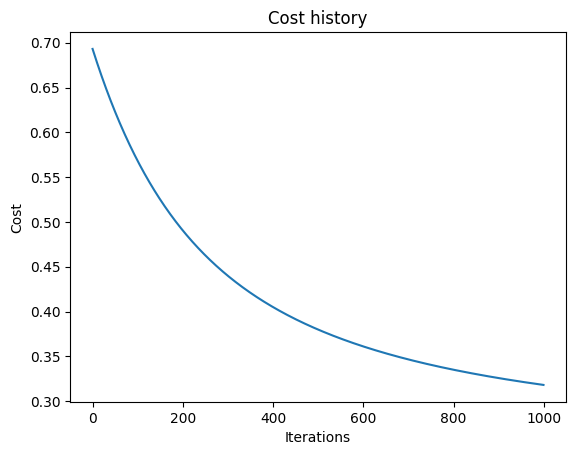

In [15]:
# plot cost history
plt.plot(range(1000), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost history')


In [16]:
# predict
y_pred = predict(X_test, theta)
y_pred = [1 if i > 0.5 else 0 for i in y_pred]


In [17]:
# accuracy
accuracy(y_test, y_pred)*100

np.float64(88.88888888888889)

In [19]:
df2 = pd.read_csv('new_customers_1.csv')
df2.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson


In [20]:
df2.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)

In [21]:
df2

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0
5,22.0,8445.26,1,3.46,14.0


In [22]:
# apply prediction on new data
X_new = scaler.transform(df2)
X_new = np.c_[np.ones((X_new.shape[0], 1)), X_new]
y_pred_new = predict(X_new, theta)
y_pred_new = [1 if i > 0.5 else 0 for i in y_pred_new]
y_pred_new

# insert prediction into dataframe
df2['Churn'] = y_pred_new
df2

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,37.0,9935.53,1,7.71,8.0,0
1,23.0,7526.94,1,9.28,15.0,1
2,65.0,100.00,1,1.00,15.0,1
3,32.0,6487.50,0,9.40,14.0,1
4,32.0,13147.71,1,10.00,8.0,0
5,22.0,8445.26,1,3.46,14.0,1


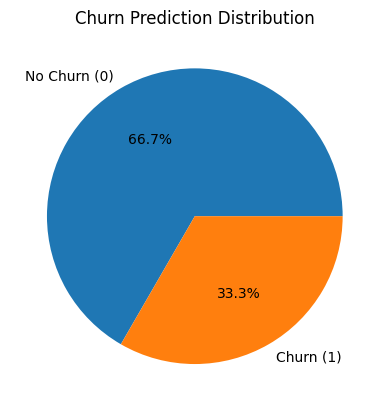

In [23]:
# count churn values
churn_counts = df2['Churn'].value_counts()

# pie chart
labels = ['No Churn (0)', 'Churn (1)']

plt.figure()
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%')
plt.title('Churn Prediction Distribution')
plt.show()

In [24]:
df.corr()['Churn'].sort_values(ascending=False)

Churn              1.000000
Num_Sites          0.525398
Years              0.214329
Age                0.085926
Account_Manager    0.070611
Total_Purchase     0.024031
Name: Churn, dtype: float64

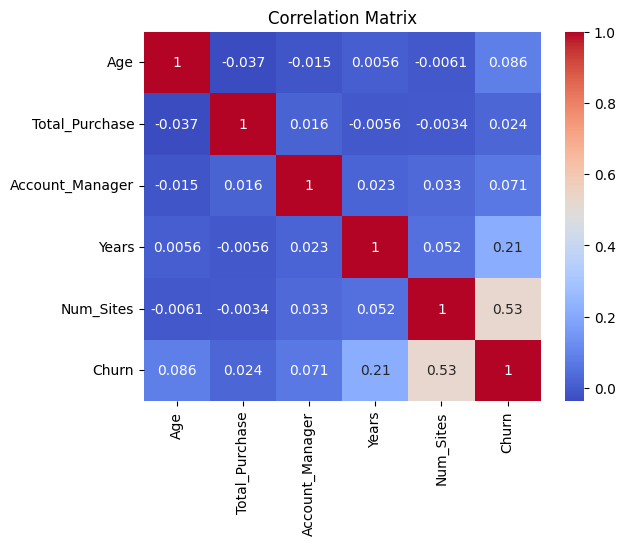

In [25]:
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Insight

Jumlah website yang menggunakan layanan (Num_Sites) merupakan faktor paling berpengaruh terhadap churn. Hal ini menunjukkan bahwa semakin banyak website yang dikelola, semakin besar kemungkinan pelanggan untuk churn.

Selain itu, lama berlangganan (Years) juga memiliki pengaruh, di mana pelanggan dengan durasi lebih pendek cenderung lebih mudah churn.

Sementara itu, variabel seperti Total_Purchase dan Account_Manager menunjukkan pengaruh yang sangat kecil terhadap churn.

Saran : Perusahaan disarankan untuk memprioritaskan pelanggan dengan jumlah website tinggi dan pelanggan baru, karena kelompok ini memiliki risiko churn lebih besar. Strategi seperti peningkatan layanan, onboarding yang lebih baik, dan penugasan account manager secara tepat dapat membantu menurunkan tingkat churn.